# PhaseNet Demo with SeisBench
# Quick test to confirm PhaseNet works and understand its outputs

## 1. Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seisbench.models as sbm
from obspy import UTCDateTime, Stream, Trace
from obspy.clients.fdsn import Client

## 2. Load Pre-trained PhaseNet Model

In [2]:
# Load PhaseNet pre-trained on the original dataset
model = sbm.PhaseNet.from_pretrained("original")  #"original" — these are the weights from the original Zhu & Beroza 2019 PhaseNet paper, trained specifically on Northern California data from NCEDC

#Note that we can also use the STEAD model in the above line since STEAD is based on global data, not Northern California

# The model outputs three probability traces: P-wave, S-wave, and Noise
print("Model labels:", model.labels)

Downloading: 100%|██████████| 1.06M/1.06M [00:00<00:00, 7.98MB/s]


Model labels: NPS


## 3. Download Real Earthquake Data

We use ObsPy's FDSN client to download waveforms from the 2020 Idaho M6.5 earthquake, recorded at station US.BOZ.

In [3]:
# Connect to IRIS data centre and download 3-component waveforms
client = Client("IRIS")

# 2020 Idaho M6.5 earthquake
t = UTCDateTime("2020-03-31T23:52:30")
st = client.get_waveforms("US", "BOZ", "00", "BH*", t, t + 120)

print(st)
for tr in st:
    print(f"  {tr.id}: {tr.stats.npts} samples at {tr.stats.sampling_rate} Hz")

3 Trace(s) in Stream:
US.BOZ.00.BH1 | 2020-03-31T23:52:30.000000Z - 2020-03-31T23:54:30.000000Z | 40.0 Hz, 4801 samples
US.BOZ.00.BH2 | 2020-03-31T23:52:30.000000Z - 2020-03-31T23:54:29.975000Z | 40.0 Hz, 4800 samples
US.BOZ.00.BHZ | 2020-03-31T23:52:30.000000Z - 2020-03-31T23:54:30.000000Z | 40.0 Hz, 4801 samples
  US.BOZ.00.BH1: 4801 samples at 40.0 Hz
  US.BOZ.00.BH2: 4800 samples at 40.0 Hz
  US.BOZ.00.BHZ: 4801 samples at 40.0 Hz


## 4. Run PhaseNet — Annotate and Classify

- `annotate()` returns continuous probability traces for P, S, and Noise
- `classify()` extracts discrete picks from those traces

In [4]:
# Get continuous probability traces
annotations = model.annotate(st)

# Get discrete picks (using lower thresholds since this is a distant station)
output = model.classify(st, P_threshold = 0.1, S_threshold = 0.1)
picks = output.picks

print("Predicted picks:")
for pick in picks:
    print(f"  Phase: {pick.phase}, Time: {pick.peak_time}, Confidence: {pick.peak_value:.4f}")

Predicted picks:
  Phase: P, Time: 2020-03-31T23:53:16.240000Z, Confidence: 0.1447
  Phase: P, Time: 2020-03-31T23:53:18.540000Z, Confidence: 0.2562
  Phase: S, Time: 2020-03-31T23:53:24.160000Z, Confidence: 0.1830
  Phase: S, Time: 2020-03-31T23:53:28.610000Z, Confidence: 0.1666
  Phase: S, Time: 2020-03-31T23:53:58.230000Z, Confidence: 0.2437
  Phase: S, Time: 2020-03-31T23:54:02.510000Z, Confidence: 0.1245


## 5. Plot Waveform with Probability Traces

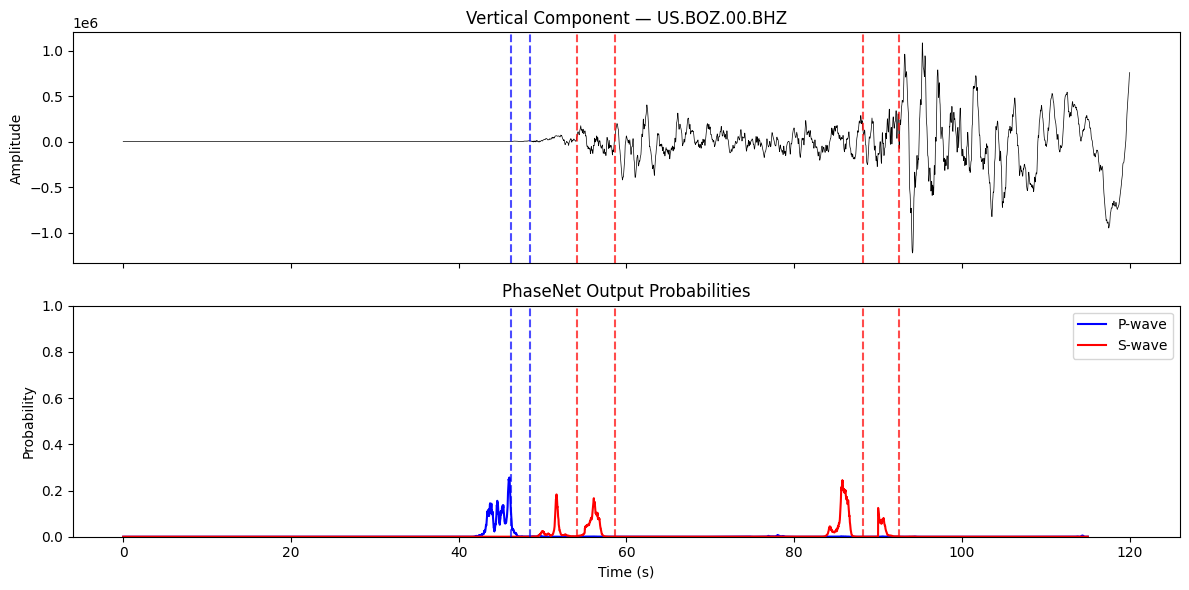

In [5]:
# Extract the vertical component (Z) for display
tr_z = st.select(channel = "BHZ")[0]

# Extract the P and S probability traces from annotations
tr_p = annotations.select(channel = "*_P")[0]
tr_s = annotations.select(channel = "*_S")[0]

# Build time axes (in seconds from start)
t_waveform = np.arange(tr_z.stats.npts) / tr_z.stats.sampling_rate
t_probs = np.arange(tr_p.stats.npts) / tr_p.stats.sampling_rate

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (12, 6), sharex = True)

# Top panel: raw waveform
ax1.plot(t_waveform, tr_z.data, "k", linewidth = 0.5)
ax1.set_ylabel("Amplitude")
ax1.set_title(f"Vertical Component — {tr_z.id}")

# Bottom panel: PhaseNet probabilities
ax2.plot(t_probs, tr_p.data, "b", label = "P-wave")
ax2.plot(t_probs, tr_s.data, "r", label = "S-wave")
ax2.set_ylabel("Probability")
ax2.set_xlabel("Time (s)")
ax2.set_title("PhaseNet Output Probabilities")
ax2.legend()
ax2.set_ylim(0, 1)

# Mark the picks with vertical lines
for pick in picks:
    # Convert pick time to seconds from start
    pick_time = pick.peak_time - tr_z.stats.starttime
    colour = "b" if pick.phase == "P" else "r"
    for ax in [ax1, ax2]:
        ax.axvline(pick_time, color = colour, linestyle = "--", alpha = 0.7)

plt.tight_layout()
plt.show()

## 6. Synthetic Example — Clearer P and S Arrivals

The real data above is from a distant station, so picks are weak. Here we create a synthetic waveform with clear P and S arrivals to see PhaseNet at its best.

In [6]:
# Build a synthetic 3-component seismogram
np.random.seed(42)
sampling_rate = 100.0
npts = 6000  # 60 seconds
t_p = 1500   # P arrival at 15s
t_s = 2500   # S arrival at 25s

traces = []
for comp in ["Z", "N", "E"]:
    data = np.random.randn(npts) * 0.01  # background noise

    # P wave: sharp onset, high frequency, strong on Z
    p_env = np.exp(-np.arange(500) / 100)
    p_signal = p_env * np.sin(2 * np.pi * 5 * np.arange(500) / sampling_rate)
    p_amp = 0.8 if comp == "Z" else 0.2
    data[t_p:t_p + 500] += p_signal * p_amp

    # S wave: broader, lower frequency, strong on N/E
    s_env = np.exp(-np.arange(800) / 150)
    s_signal = s_env * np.sin(2 * np.pi * 2 * np.arange(800) / sampling_rate)
    s_amp = 0.3 if comp == "Z" else 1.0
    data[t_s:t_s + 800] += s_signal * s_amp

    tr = Trace(data = data.astype(np.float32))
    tr.stats.sampling_rate = sampling_rate
    tr.stats.network = "SY"
    tr.stats.station = "TEST"
    tr.stats.location = "00"
    tr.stats.channel = f"BH{comp}"
    tr.stats.starttime = UTCDateTime("2024-01-01T00:00:00")
    traces.append(tr)

st_syn = Stream(traces)
print(st_syn)

3 Trace(s) in Stream:
SY.TEST.00.BHZ | 2024-01-01T00:00:00.000000Z - 2024-01-01T00:00:59.990000Z | 100.0 Hz, 6000 samples
SY.TEST.00.BHN | 2024-01-01T00:00:00.000000Z - 2024-01-01T00:00:59.990000Z | 100.0 Hz, 6000 samples
SY.TEST.00.BHE | 2024-01-01T00:00:00.000000Z - 2024-01-01T00:00:59.990000Z | 100.0 Hz, 6000 samples


In [7]:
# Run PhaseNet on the synthetic data
annotations_syn = model.annotate(st_syn)
output_syn = model.classify(st_syn)
picks_syn = output_syn.picks

print("Predicted picks (synthetic):")
for pick in picks_syn:
    print(f"  Phase: {pick.phase}, Time: {pick.peak_time}, Confidence: {pick.peak_value:.4f}")

Predicted picks (synthetic):
  Phase: P, Time: 2024-01-01T00:00:14.990000Z, Confidence: 0.9428
  Phase: S, Time: 2024-01-01T00:00:25.000000Z, Confidence: 0.6954


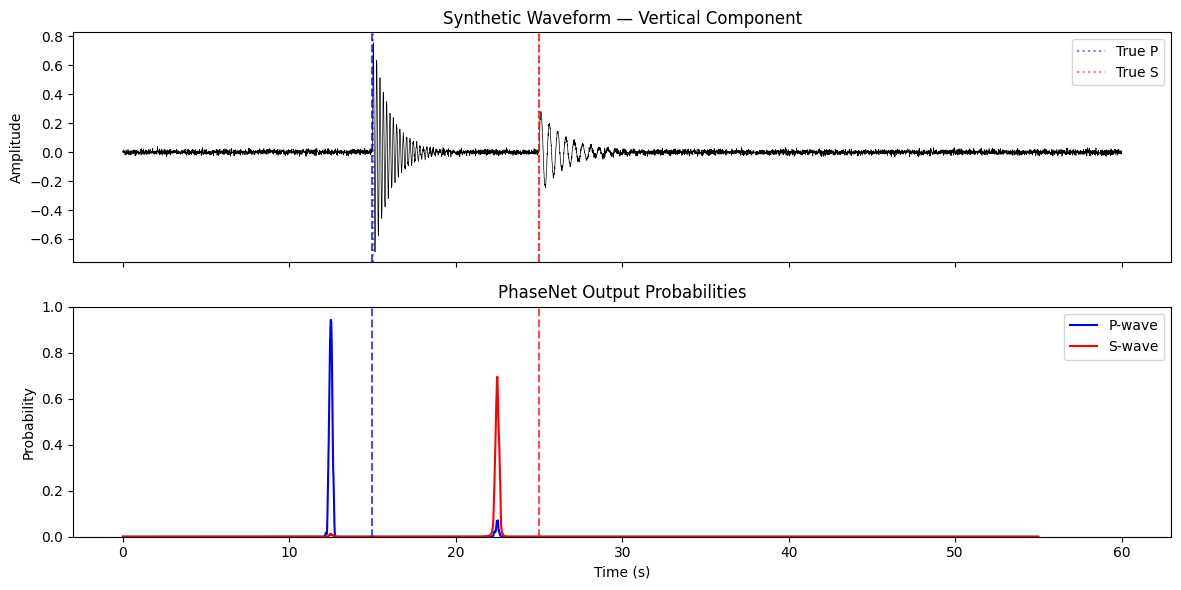

In [8]:
# Plot the synthetic waveform and PhaseNet outputs
tr_z_syn = st_syn.select(channel = "BHZ")[0]
tr_p_syn = annotations_syn.select(channel = "*_P")[0]
tr_s_syn = annotations_syn.select(channel = "*_S")[0]

t_wav = np.arange(tr_z_syn.stats.npts) / tr_z_syn.stats.sampling_rate
t_prob = np.arange(tr_p_syn.stats.npts) / tr_p_syn.stats.sampling_rate

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (12, 6), sharex = True)

# Top: waveform
ax1.plot(t_wav, tr_z_syn.data, "k", linewidth = 0.5)
ax1.set_ylabel("Amplitude")
ax1.set_title("Synthetic Waveform — Vertical Component")

# True arrival times for reference
ax1.axvline(t_p / sampling_rate, color = "b", linestyle = ":", alpha = 0.5, label = "True P")
ax1.axvline(t_s / sampling_rate, color = "r", linestyle = ":", alpha = 0.5, label = "True S")
ax1.legend(loc = "upper right")

# Bottom: probabilities
ax2.plot(t_prob, tr_p_syn.data, "b", label = "P-wave")
ax2.plot(t_prob, tr_s_syn.data, "r", label = "S-wave")
ax2.set_ylabel("Probability")
ax2.set_xlabel("Time (s)")
ax2.set_title("PhaseNet Output Probabilities")
ax2.legend()
ax2.set_ylim(0, 1)

# Mark predicted picks
for pick in picks_syn:
    pick_time = pick.peak_time - tr_z_syn.stats.starttime
    colour = "b" if pick.phase == "P" else "r"
    for ax in [ax1, ax2]:
        ax.axvline(pick_time, color = colour, linestyle = "--", alpha = 0.7)

plt.tight_layout()
plt.show()